# Bayesian Optimization Deep Dive for Materials Informatics

This notebook is designed for a class sequence where we have already covered naive Bayes and Gaussian processes.

**Goals**
- Connect the Gaussian process posterior from the previous class to the Bayesian optimization loop.
- Build intuition for surrogate models, acquisition functions, and the exploration vs. exploitation tradeoff.
- Work through materials-focused examples, including a real silver nanoparticle synthesis dataset.
- See how single-objective, multi-objective, constrained, and batch settings show up in materials science.


In [1]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_PATH = Path("AgNP_dataset.csv")
rng = np.random.default_rng(7)


## 1. From Gaussian Processes to Bayesian Optimization

A Gaussian process gives us a predictive **mean** and **uncertainty** over a function we have not fully observed yet.
Bayesian optimization adds a decision rule on top of that posterior:

$$
\text{next experiment} = \arg\max_x \ \alpha(x \mid \mathcal{D})
$$

where $\alpha$ is an **acquisition function** such as:
- Probability of Improvement (PI)
- Upper Confidence Bound (UCB)
- Expected Improvement (EI)

In materials science, this matters because each experiment or simulation can be expensive:
wet-lab synthesis, DFT calculations, high-temperature processing runs, or long cycling experiments.


### Symbol and Variable Guide

Before jumping into code, here is the meaning of the main symbols and variables that appear throughout the notebook.


In [2]:
symbol_guide = pd.DataFrame(
    [
        {"Symbol / variable": "$x$", "Meaning": "A candidate material, recipe, or processing condition."},
        {"Symbol / variable": "$y$", "Meaning": "The measured property we care about, such as yield, loss, stability, or strength."},
        {"Symbol / variable": "$\μ(x)$", "Meaning": "The GP posterior mean: our current best prediction at x."},
        {"Symbol / variable": "$\σ(x)$", "Meaning": "The GP posterior standard deviation: our uncertainty at x."},
        {"Symbol / variable": "$\alpha(x)$", "Meaning": "The acquisition score that tells us how attractive x is as the next experiment."},
        {"Symbol / variable": "`xi`", "Meaning": "Improvement bonus in PI/EI. Larger values encourage more exploration."},
        {"Symbol / variable": "`kappa`", "Meaning": "Exploration weight in UCB. Larger values place more weight on uncertainty."},
        {"Symbol / variable": "`X_obs`, `y_obs`", "Meaning": "Experiments we have already performed and their measured outcomes."},
        {"Symbol / variable": "`X_grid`", "Meaning": "Candidate points where we evaluate the surrogate and acquisition function."},
    ]
)
display(symbol_guide)


,Symbol / variable,Meaning
0,$x$,"A candidate material, recipe, or processing co..."
1,$y$,"The measured property we care about, such as y..."
2,$\μ(x)$,The GP posterior mean: our current best predic...
3,$\σ(x)$,The GP posterior standard deviation: our uncer...
4,$lpha(x)$,The acquisition score that tells us how attrac...
5,`xi`,Improvement bonus in PI/EI. Larger values enco...
6,`kappa`,Exploration weight in UCB. Larger values place...
7,"`X_obs`, `y_obs`",Experiments we have already performed and thei...
8,`X_grid`,Candidate points where we evaluate the surroga...


In [3]:
def synthetic_objective(x):
    x = np.asarray(x)
    return (
        np.sin(2.7 * x)
        + 0.35 * np.cos(8.0 * x)
        - 0.08 * (x - 2.8) ** 2
    )


def build_gp():
    kernel = (
        ConstantKernel(1.0, constant_value_bounds="fixed")
        * Matern(length_scale=0.55, length_scale_bounds="fixed", nu=2.5)
        + WhiteKernel(noise_level=1e-6, noise_level_bounds="fixed")
    )
    return GaussianProcessRegressor(
        kernel=kernel,
        optimizer=None,
        normalize_y=True,
    )


def probability_of_improvement(mu, sigma, best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    z = (mu - best - xi) / sigma
    return norm.cdf(z)


def upper_confidence_bound(mu, sigma, kappa=1.5):
    return mu + kappa * sigma


def expected_improvement(mu, sigma, best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - best - xi
    z = improvement / sigma
    return improvement * norm.cdf(z) + sigma * norm.pdf(z)


X_grid = np.linspace(0.0, 4.0, 400).reshape(-1, 1)
y_grid = synthetic_objective(X_grid).ravel()

X_obs = np.array([0.15, 0.75, 1.35, 2.1, 3.35]).reshape(-1, 1)
y_obs = synthetic_objective(X_obs).ravel()

gp0 = build_gp()
gp0.fit(X_obs, y_obs)
mu0, sigma0 = gp0.predict(X_grid, return_std=True)

best_so_far = y_obs.max()
pi0 = probability_of_improvement(mu0, sigma0, best_so_far)
ucb0 = upper_confidence_bound(mu0, sigma0)
ei0 = expected_improvement(mu0, sigma0, best_so_far)


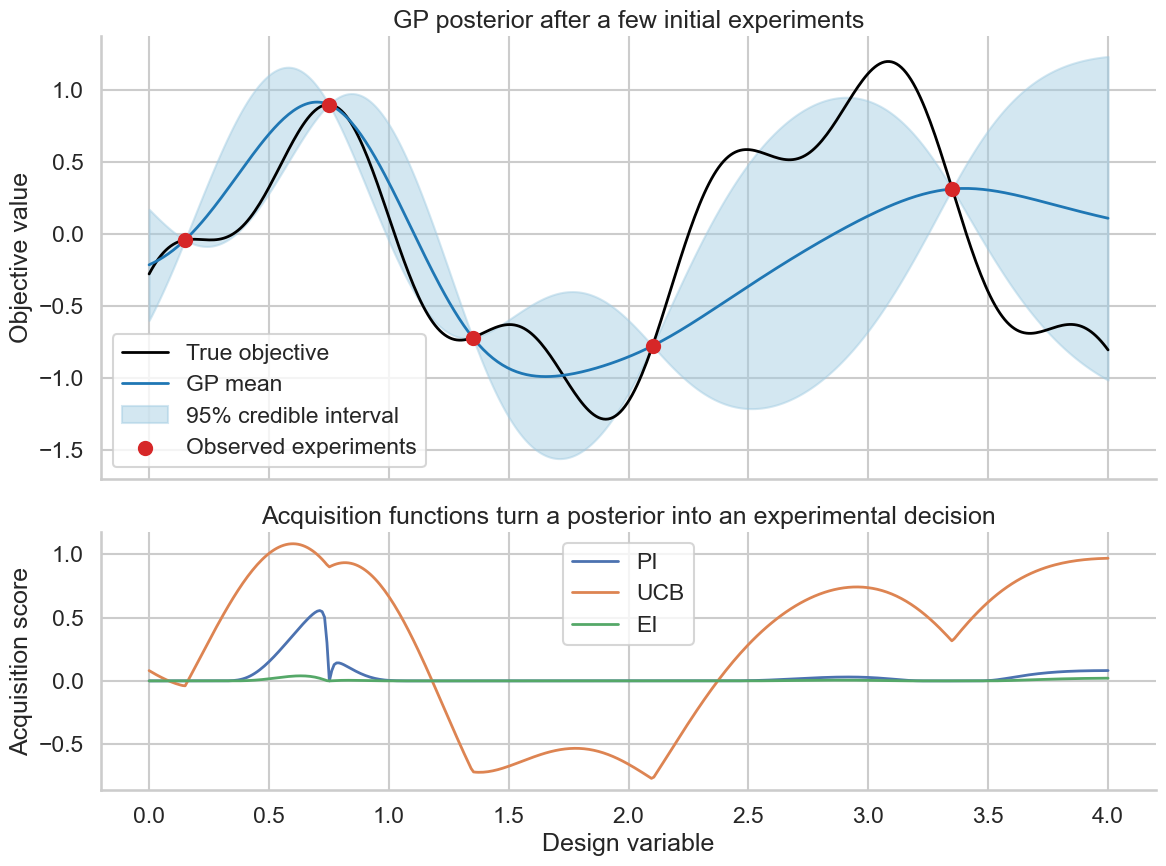

In [4]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.4]},
)

axes[0].plot(X_grid, y_grid, color="black", linewidth=2, label="True objective")
axes[0].plot(X_grid, mu0, color="#1f77b4", linewidth=2, label="GP mean")
axes[0].fill_between(
    X_grid.ravel(),
    mu0 - 1.96 * sigma0,
    mu0 + 1.96 * sigma0,
    color="#9ecae1",
    alpha=0.45,
    label="95% credible interval",
)
axes[0].scatter(X_obs, y_obs, color="#d62728", s=90, zorder=5, label="Observed experiments")
axes[0].set_ylabel("Objective value")
axes[0].set_title("GP posterior after a few initial experiments")
axes[0].legend(loc="best")

axes[1].plot(X_grid, pi0, label="PI", linewidth=2)
axes[1].plot(X_grid, ucb0, label="UCB", linewidth=2)
axes[1].plot(X_grid, ei0, label="EI", linewidth=2)
axes[1].set_xlabel("Design variable")
axes[1].set_ylabel("Acquisition score")
axes[1].set_title("Acquisition functions turn a posterior into an experimental decision")
axes[1].legend(loc="best")

plt.tight_layout()


**Interpretation**

- The GP mean is our current best guess of the response surface.
- The uncertainty band is widest where we have little or no data.
- PI/UCB/EI all reward promising regions, but they balance promise and uncertainty differently.
- EI is often a nice teaching default because it directly measures the expected amount of improvement.


### Interactive Acquisition Playground

Use the controls below to ask a classroom question like:
**"If we reward uncertainty more strongly, where does the algorithm want to sample next?"**


In [5]:
def plot_acquisition_playground(acquisition="EI", xi=0.01, kappa=1.5):
    gp = build_gp()
    gp.fit(X_obs, y_obs)
    mu, sigma = gp.predict(X_grid, return_std=True)

    acquisition = acquisition.upper()
    if acquisition == "PI":
        scores = probability_of_improvement(mu, sigma, y_obs.max(), xi=xi)
        subtitle = f"PI with xi={xi:.2f}"
    elif acquisition == "UCB":
        scores = upper_confidence_bound(mu, sigma, kappa=kappa)
        subtitle = f"UCB with kappa={kappa:.2f}"
    else:
        scores = expected_improvement(mu, sigma, y_obs.max(), xi=xi)
        subtitle = f"EI with xi={xi:.2f}"

    next_idx = int(np.argmax(scores))
    x_next = float(X_grid[next_idx, 0])
    y_next = float(y_grid[next_idx])

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.2]},
    )

    axes[0].plot(X_grid, y_grid, color="black", linewidth=2, label="True objective")
    axes[0].plot(X_grid, mu, color="#1f77b4", linewidth=2, label="GP mean")
    axes[0].fill_between(
        X_grid.ravel(),
        mu - 1.96 * sigma,
        mu + 1.96 * sigma,
        color="#9ecae1",
        alpha=0.45,
        label="95% credible interval",
    )
    axes[0].scatter(X_obs, y_obs, color="#d62728", s=90, zorder=5, label="Observed experiments")
    axes[0].axvline(x_next, color="#2ca02c", linestyle="--", linewidth=2, label="Suggested next experiment")
    axes[0].scatter([x_next], [y_next], color="#2ca02c", s=110, zorder=6)
    axes[0].set_ylabel("Objective value")
    axes[0].set_title("Posterior and suggested next experiment")
    axes[0].legend(loc="best")

    axes[1].plot(X_grid, scores, color="#9467bd", linewidth=2.5)
    axes[1].fill_between(X_grid.ravel(), 0, scores, color="#c5b0d5", alpha=0.45)
    axes[1].axvline(x_next, color="#2ca02c", linestyle="--", linewidth=2)
    axes[1].set_xlabel("Design variable")
    axes[1].set_ylabel("Acquisition score")
    axes[1].set_title(subtitle)
    plt.tight_layout()
    plt.show()

    display(
        Markdown(
            f"**Next suggested experiment:** x = `{x_next:.3f}` with true objective value `{y_next:.3f}`."
        )
    )


widgets.interact(
    plot_acquisition_playground,
    acquisition=widgets.Dropdown(options=["EI", "PI", "UCB"], value="EI", description="Rule"),
    xi=widgets.FloatSlider(value=0.01, min=0.0, max=0.5, step=0.01, description="xi"),
    kappa=widgets.FloatSlider(value=1.5, min=0.1, max=4.0, step=0.1, description="kappa"),
)


interactive(children=(Dropdown(description='Rule', options=('EI', 'PI', 'UCB'), value='EI'), FloatSlider(value…

<function __main__.plot_acquisition_playground(acquisition='EI', xi=0.01, kappa=1.5)>

In [6]:
initial_design_pool = np.array([0.15, 0.55, 0.95, 1.35, 2.10, 2.65, 3.35, 3.75]).reshape(-1, 1)


def run_synthetic_bo(n_steps=12, acquisition="EI", xi=0.01, kappa=1.5, n_initial=5):
    X_current = initial_design_pool[:n_initial].copy()
    y_current = synthetic_objective(X_current).ravel()
    snapshots = []

    for step in range(n_steps):
        gp = build_gp()
        gp.fit(X_current, y_current)
        mu, sigma = gp.predict(X_grid, return_std=True)
        acquisition = acquisition.upper()
        if acquisition == "PI":
            scores = probability_of_improvement(mu, sigma, y_current.max(), xi=xi)
        elif acquisition == "UCB":
            scores = upper_confidence_bound(mu, sigma, kappa=kappa)
        else:
            scores = expected_improvement(mu, sigma, y_current.max(), xi=xi)
        next_index = int(np.argmax(scores))
        x_next = X_grid[next_index].reshape(1, 1)
        y_next = synthetic_objective(x_next).reshape(-1)

        snapshots.append(
            {
                "step": step + 1,
                "x_next": float(x_next[0, 0]),
                "y_next": float(y_next[0]),
                "best_before": float(y_current.max()),
                "best_after": float(max(y_current.max(), y_next[0])),
            }
        )

        X_current = np.vstack([X_current, x_next])
        y_current = np.concatenate([y_current, y_next])

    return X_current, y_current, pd.DataFrame(snapshots)


X_final, y_final, synthetic_log = run_synthetic_bo()
display(synthetic_log.head(8))


,step,x_next,y_next,best_before,best_after
0,1,0.721805,0.889539,0.483755,0.889539
1,2,4.000000,-0.804158,0.889539,0.889539
2,3,3.027569,1.159155,0.889539,1.159155
3,4,3.187970,1.043417,1.159155,1.159155
4,5,2.847118,0.738560,1.159155,1.159155
5,6,3.077694,1.197001,1.159155,1.197001
6,7,3.528822,-0.495019,1.197001,1.197001
7,8,2.516291,0.582528,1.197001,1.197001


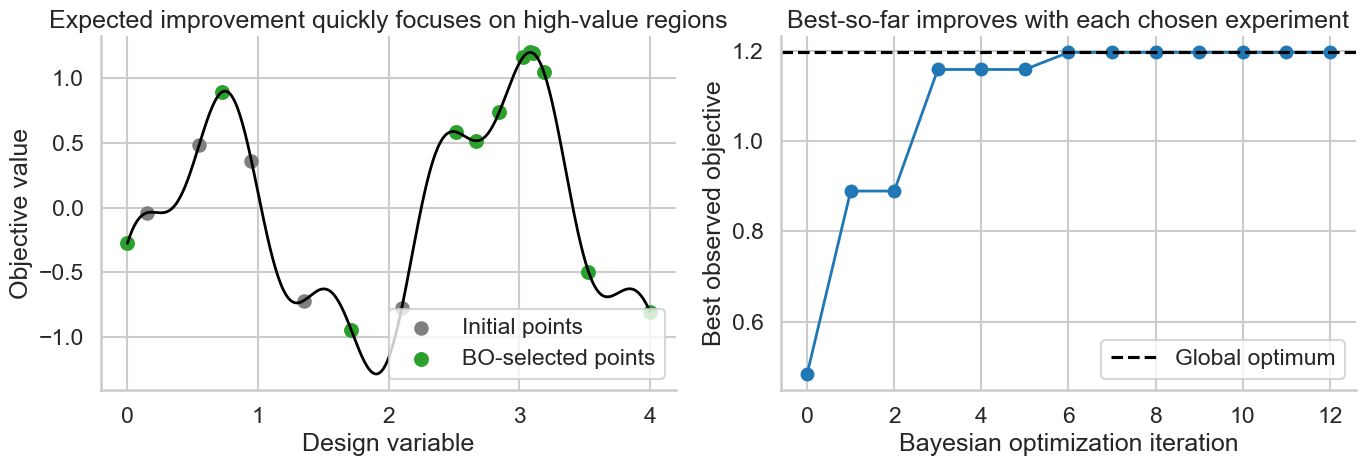

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_initial_default = 5

axes[0].plot(X_grid, y_grid, color="black", linewidth=2)
axes[0].scatter(X_final[:n_initial_default], y_final[:n_initial_default], color="#7f7f7f", s=80, label="Initial points")
axes[0].scatter(X_final[n_initial_default:], y_final[n_initial_default:], color="#2ca02c", s=85, label="BO-selected points")
axes[0].set_xlabel("Design variable")
axes[0].set_ylabel("Objective value")
axes[0].set_title("Expected improvement quickly focuses on high-value regions")
axes[0].legend(loc="best")

best_trace = [y_final[: i].max() for i in range(n_initial_default, len(X_final) + 1)]
axes[1].plot(range(len(best_trace)), best_trace, marker="o", linewidth=2, color="#1f77b4")
axes[1].axhline(y_grid.max(), linestyle="--", color="black", label="Global optimum")
axes[1].set_xlabel("Bayesian optimization iteration")
axes[1].set_ylabel("Best observed objective")
axes[1].set_title("Best-so-far improves with each chosen experiment")
axes[1].legend(loc="best")

plt.tight_layout()


### Interactive Optimization Loop

This widget lets students change the acquisition rule, how exploratory it is, the number of initial experiments, and the BO budget.
It is useful for in-class questions like:

- How sensitive is the trajectory to the initial design?
- What changes when we use UCB instead of EI?
- Does more exploration help early or late in the campaign?


In [8]:
def explore_bo_trajectory(acquisition="EI", xi=0.01, kappa=1.5, n_initial=5, n_steps=10):
    X_run, y_run, run_log = run_synthetic_bo(
        n_steps=n_steps,
        acquisition=acquisition,
        xi=xi,
        kappa=kappa,
        n_initial=n_initial,
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(X_grid, y_grid, color="black", linewidth=2)
    axes[0].scatter(X_run[:n_initial], y_run[:n_initial], color="#7f7f7f", s=80, label="Initial design")
    axes[0].scatter(X_run[n_initial:], y_run[n_initial:], color="#2ca02c", s=85, label="BO suggestions")
    axes[0].set_xlabel("Design variable")
    axes[0].set_ylabel("Objective value")
    axes[0].set_title(f"{acquisition} trajectory with {n_initial} initial points")
    axes[0].legend(loc="best")

    best_trace = [y_run[:i].max() for i in range(n_initial, len(X_run) + 1)]
    axes[1].plot(range(len(best_trace)), best_trace, marker="o", linewidth=2.2, color="#1f77b4")
    axes[1].axhline(y_grid.max(), linestyle="--", color="black", label="Global optimum")
    axes[1].set_xlabel("BO iteration")
    axes[1].set_ylabel("Best observed objective")
    axes[1].set_title("Best-so-far trajectory")
    axes[1].legend(loc="best")
    plt.tight_layout()
    plt.show()

    display(run_log.head(min(8, len(run_log))))


widgets.interact(
    explore_bo_trajectory,
    acquisition=widgets.Dropdown(options=["EI", "PI", "UCB"], value="EI", description="Rule"),
    xi=widgets.FloatSlider(value=0.01, min=0.0, max=0.5, step=0.01, description="xi"),
    kappa=widgets.FloatSlider(value=1.5, min=0.1, max=4.0, step=0.1, description="kappa"),
    n_initial=widgets.IntSlider(value=5, min=3, max=8, step=1, description="initial"),
    n_steps=widgets.IntSlider(value=10, min=4, max=18, step=1, description="steps"),
)


interactive(children=(Dropdown(description='Rule', options=('EI', 'PI', 'UCB'), value='EI'), FloatSlider(value…

<function __main__.explore_bo_trajectory(acquisition='EI', xi=0.01, kappa=1.5, n_initial=5, n_steps=10)>

## 2. Why Materials Science Is a Natural Home for Bayesian Optimization

Bayesian optimization is a strong fit whenever each function evaluation is expensive, noisy, and information-rich.
That describes many materials workflows.


In [9]:
example_table = pd.DataFrame(
    [
        {
            "Materials problem": "Silver nanoparticle synthesis",
            "Design variables": "Flow rates, precursor fractions, seed fraction",
            "Objective(s)": "Minimize optical loss or size dispersion",
            "Why BO helps": "Each experiment consumes reagents and instrument time",
        },
        {
            "Materials problem": "Battery cathode formulation",
            "Design variables": "Composition, calcination temperature, dwell time",
            "Objective(s)": "Maximize capacity and cycle life",
            "Why BO helps": "Multi-objective tradeoffs and limited synthesis budget",
        },
        {
            "Materials problem": "Perovskite processing",
            "Design variables": "Solvent ratio, spin speed, anneal profile",
            "Objective(s)": "Maximize PCE while maintaining stability",
            "Why BO helps": "Nonlinear response surfaces and unstable experiments",
        },
        {
            "Materials problem": "Electrocatalyst discovery",
            "Design variables": "Alloy composition, support, pH, loading",
            "Objective(s)": "Maximize activity and durability",
            "Why BO helps": "Expensive characterization and many coupled variables",
        },
        {
            "Materials problem": "Additive manufacturing of alloys",
            "Design variables": "Laser power, scan speed, hatch spacing",
            "Objective(s)": "Minimize porosity, maximize strength",
            "Why BO helps": "Parallel constraints and small high-value datasets",
        },
    ]
)
display(example_table)


,Materials problem,Design variables,Objective(s),Why BO helps
0,Silver nanoparticle synthesis,"Flow rates, precursor fractions, seed fraction",Minimize optical loss or size dispersion,Each experiment consumes reagents and instrume...
1,Battery cathode formulation,"Composition, calcination temperature, dwell time",Maximize capacity and cycle life,Multi-objective tradeoffs and limited synthesi...
2,Perovskite processing,"Solvent ratio, spin speed, anneal profile",Maximize PCE while maintaining stability,Nonlinear response surfaces and unstable exper...
3,Electrocatalyst discovery,"Alloy composition, support, pH, loading",Maximize activity and durability,Expensive characterization and many coupled va...
4,Additive manufacturing of alloys,"Laser power, scan speed, hatch spacing","Minimize porosity, maximize strength",Parallel constraints and small high-value data...


## 3. Real Example: Silver Nanoparticle Optimization

Here we treat the existing dataset as a catalog of experiments that a student team could choose from sequentially.
Because there are repeated rows, we first average the repeated measurements so each unique condition becomes a single candidate experiment.


In [10]:
df = pd.read_csv(DATA_PATH)
feature_cols = ["QAgNO3(%)", "Qpva(%)", "Qtsc(%)", "Qseed(%)", "Qtot(uL/min)"]
agnp = (
    df.groupby(feature_cols, as_index=False)["loss"]
    .mean()
    .sort_values("loss", ascending=True)
    .reset_index(drop=True)
)

print(f"Raw rows: {len(df):,}")
print(f"Unique experimental conditions: {len(agnp):,}")
print(f"Best averaged loss in the catalog: {agnp['loss'].min():.4f}")

display(agnp.head(10))


Raw rows: 3,295
Unique experimental conditions: 164
Best averaged loss in the catalog: 0.1484


,QAgNO3(%),Qpva(%),Qtsc(%),Qseed(%),Qtot(uL/min),loss
0,32.501176,16.000000,6.501176,4.501176,850.00,0.148361
1,36.500000,22.000000,2.500000,6.500000,900.00,0.169340
2,30.500000,38.000000,0.500000,6.500000,900.00,0.171847
3,34.500000,18.000000,2.500000,6.500000,900.00,0.173749
4,33.360430,20.100503,5.108878,5.399547,811.92,0.175292
5,32.501053,30.000000,0.501053,6.501053,950.00,0.189082
6,28.501053,24.000000,2.501053,6.501053,950.00,0.201183
7,32.500000,22.000000,0.500000,6.500000,900.00,0.218098
8,25.479939,37.590147,2.079736,4.591163,787.60,0.228098
9,38.421553,38.529319,4.301109,7.990491,631.00,0.232589


### What Do These AgNP Variables Mean?

This is a good place to pause and ask students which variables are likely to be most influential before showing the correlation plot.


In [11]:
agnp_glossary = pd.DataFrame(
    [
        {"Column": "QAgNO3(%)", "Interpretation": "Silver nitrate fraction. Controls the precursor available for nanoparticle formation."},
        {"Column": "Qpva(%)", "Interpretation": "Polyvinyl alcohol fraction. Acts like a stabilizer or process modifier."},
        {"Column": "Qtsc(%)", "Interpretation": "Reducing-agent-related fraction. Influences nucleation and growth kinetics."},
        {"Column": "Qseed(%)", "Interpretation": "Seed fraction. Can strongly affect particle growth pathways and size distribution."},
        {"Column": "Qtot(uL/min)", "Interpretation": "Total flow rate. Changes residence time and mixing conditions."},
        {"Column": "loss", "Interpretation": "Response variable to minimize in this dataset."},
    ]
)
display(agnp_glossary)


,Column,Interpretation
0,QAgNO3(%),Silver nitrate fraction. Controls the precurso...
1,Qpva(%),Polyvinyl alcohol fraction. Acts like a stabil...
2,Qtsc(%),Reducing-agent-related fraction. Influences nu...
3,Qseed(%),Seed fraction. Can strongly affect particle gr...
4,Qtot(uL/min),Total flow rate. Changes residence time and mi...
5,loss,Response variable to minimize in this dataset.


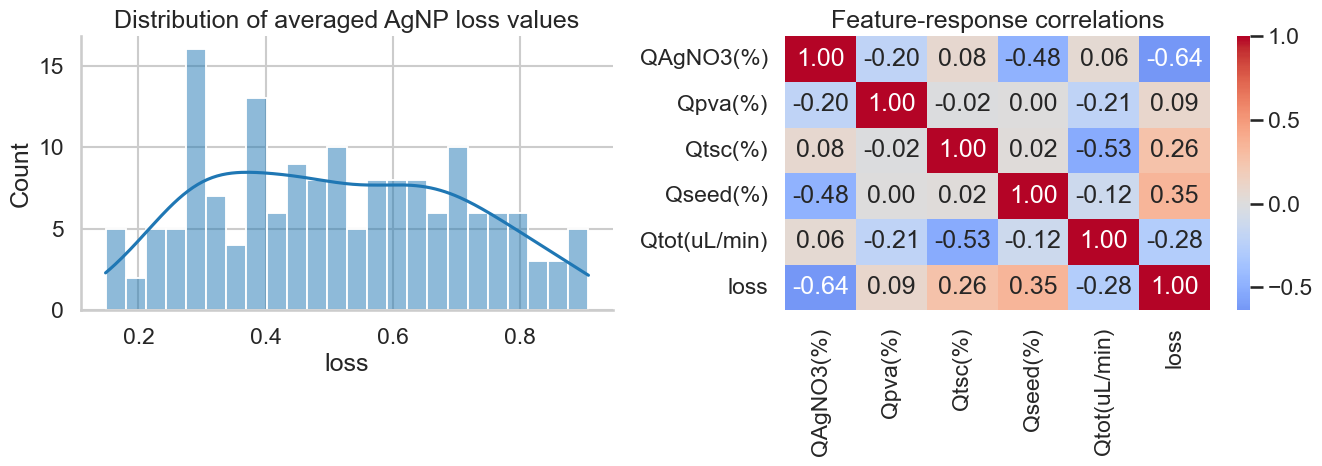

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(agnp["loss"], bins=24, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribution of averaged AgNP loss values")

corr = agnp[feature_cols + ["loss"]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Feature-response correlations")

plt.tight_layout()


### Discrete Bayesian Optimization on a Fixed Experimental Catalog

In practice, a lab often chooses the next experiment from a **finite list of allowed recipes** rather than from a mathematically continuous search space.
We can emulate that by:

1. fitting a GP on the experiments we have already tried,
2. scoring the **untested** recipes with an acquisition function,
3. selecting the highest-scoring candidate for the next run.

Since the dataset uses **loss**, we will **minimize** rather than maximize.


In [13]:
X_catalog = agnp[feature_cols].to_numpy()
y_catalog = agnp["loss"].to_numpy()

scaler = MinMaxScaler().fit(X_catalog)
X_scaled = scaler.transform(X_catalog)

discrete_kernel = (
    ConstantKernel(1.0, constant_value_bounds="fixed")
    * Matern(length_scale=np.full(X_scaled.shape[1], 0.25), length_scale_bounds="fixed", nu=2.5)
    + WhiteKernel(noise_level=1e-5, noise_level_bounds="fixed")
)


def expected_improvement_min(mu, sigma, best, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = best - mu - xi
    z = improvement / sigma
    return improvement * norm.cdf(z) + sigma * norm.pdf(z)


def fit_catalog_gp(X_train, y_train):
    gp = GaussianProcessRegressor(
        kernel=discrete_kernel,
        optimizer=None,
        normalize_y=True,
    )
    gp.fit(X_train, y_train)
    return gp


def run_catalog_bo(strategy="ei", n_init=6, n_steps=15, seed=0):
    local_rng = np.random.default_rng(seed)
    chosen = list(local_rng.choice(len(X_scaled), size=n_init, replace=False))
    records = []

    for step in range(n_steps):
        remaining = np.setdiff1d(np.arange(len(X_scaled)), np.array(chosen), assume_unique=False)

        if strategy == "random":
            next_idx = int(local_rng.choice(remaining))
        else:
            gp = fit_catalog_gp(X_scaled[chosen], y_catalog[chosen])
            mu, sigma = gp.predict(X_scaled[remaining], return_std=True)
            scores = expected_improvement_min(mu, sigma, y_catalog[chosen].min(), xi=0.005)
            next_idx = int(remaining[np.argmax(scores)])

        chosen.append(next_idx)
        best_loss = float(y_catalog[chosen].min())
        records.append(
            {
                "step": step + 1,
                "selected_index": next_idx,
                "selected_loss": float(y_catalog[next_idx]),
                "best_loss_so_far": best_loss,
            }
        )

    return chosen, pd.DataFrame(records)


def summarize_strategy(strategy, runs=40, n_init=6, n_steps=15):
    traces = []
    final_best = []
    for seed in range(runs):
        chosen, _ = run_catalog_bo(strategy=strategy, n_init=n_init, n_steps=n_steps, seed=seed)
        best_curve = [y_catalog[chosen[:i]].min() for i in range(n_init, len(chosen) + 1)]
        traces.append(best_curve)
        final_best.append(best_curve[-1])
    return np.array(traces), np.array(final_best)


In [14]:
chosen_ei, ei_log = run_catalog_bo(strategy="ei", seed=11)
display(ei_log.head(8))

chosen_rows = agnp.iloc[chosen_ei].copy()
chosen_rows["selection_order"] = range(len(chosen_rows))
display(chosen_rows.nsmallest(8, "loss"))


,step,selected_index,selected_loss,best_loss_so_far
0,1,1,0.169340,0.16934
1,2,3,0.173749,0.16934
2,3,7,0.218098,0.16934
3,4,43,0.366709,0.16934
4,5,5,0.189082,0.16934
5,6,2,0.171847,0.16934
6,7,13,0.257858,0.16934
7,8,10,0.239321,0.16934


,QAgNO3(%),Qpva(%),Qtsc(%),Qseed(%),Qtot(uL/min),loss,selection_order
1,36.500000,22.000000,2.500000,6.500000,900.00,0.169340,6
2,30.500000,38.000000,0.500000,6.500000,900.00,0.171847,11
3,34.500000,18.000000,2.500000,6.500000,900.00,0.173749,7
5,32.501053,30.000000,0.501053,6.501053,950.00,0.189082,10
7,32.500000,22.000000,0.500000,6.500000,900.00,0.218098,8
9,38.421553,38.529319,4.301109,7.990491,631.00,0.232589,14
10,28.500000,36.000000,0.500000,6.500000,900.00,0.239321,13
13,27.150551,39.891266,2.438900,6.569788,787.24,0.257858,12


### Interactive AgNP Campaign Explorer

The widget below lets you explore a realistic question for the lab:
**If we have only a small number of experimental rounds, how much does Bayesian optimization help compared with random search?**


In [15]:
def explore_catalog_campaign(strategy="ei", n_init=6, n_steps=12, seed=11):
    chosen, log_df = run_catalog_bo(strategy=strategy, n_init=n_init, n_steps=n_steps, seed=seed)
    chosen_table = agnp.iloc[chosen].copy()
    chosen_table["selection_order"] = range(len(chosen_table))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(
        data=agnp,
        x="QAgNO3(%)",
        y="loss",
        color="#c7c7c7",
        s=70,
        ax=axes[0],
        label="Catalog conditions",
    )
    sns.scatterplot(
        data=chosen_table,
        x="QAgNO3(%)",
        y="loss",
        hue="selection_order",
        palette="viridis",
        s=110,
        ax=axes[0],
        legend=False,
    )
    axes[0].set_title(f"Selected AgNP conditions with strategy = {strategy}")

    best_trace = [y_catalog[chosen[:i]].min() for i in range(n_init, len(chosen) + 1)]
    axes[1].plot(range(len(best_trace)), best_trace, marker="o", linewidth=2.2, color="#1f77b4")
    axes[1].axhline(y_catalog.min(), linestyle="--", color="black", label="Best in catalog")
    axes[1].set_xlabel("Campaign step")
    axes[1].set_ylabel("Best observed loss")
    axes[1].set_title("Best-so-far loss over the campaign")
    axes[1].legend(loc="best")
    plt.tight_layout()
    plt.show()

    display(log_df.head(min(10, len(log_df))))


widgets.interact(
    explore_catalog_campaign,
    strategy=widgets.Dropdown(options=["ei", "random"], value="ei", description="strategy"),
    n_init=widgets.IntSlider(value=6, min=4, max=12, step=1, description="initial"),
    n_steps=widgets.IntSlider(value=12, min=4, max=24, step=1, description="steps"),
    seed=widgets.IntSlider(value=11, min=0, max=40, step=1, description="seed"),
)


interactive(children=(Dropdown(description='strategy', options=('ei', 'random'), value='ei'), IntSlider(value=…

<function __main__.explore_catalog_campaign(strategy='ei', n_init=6, n_steps=12, seed=11)>

Mean final best loss with EI:     0.1637
Mean final best loss with random: 0.1981
Global best loss in catalog:      0.1484


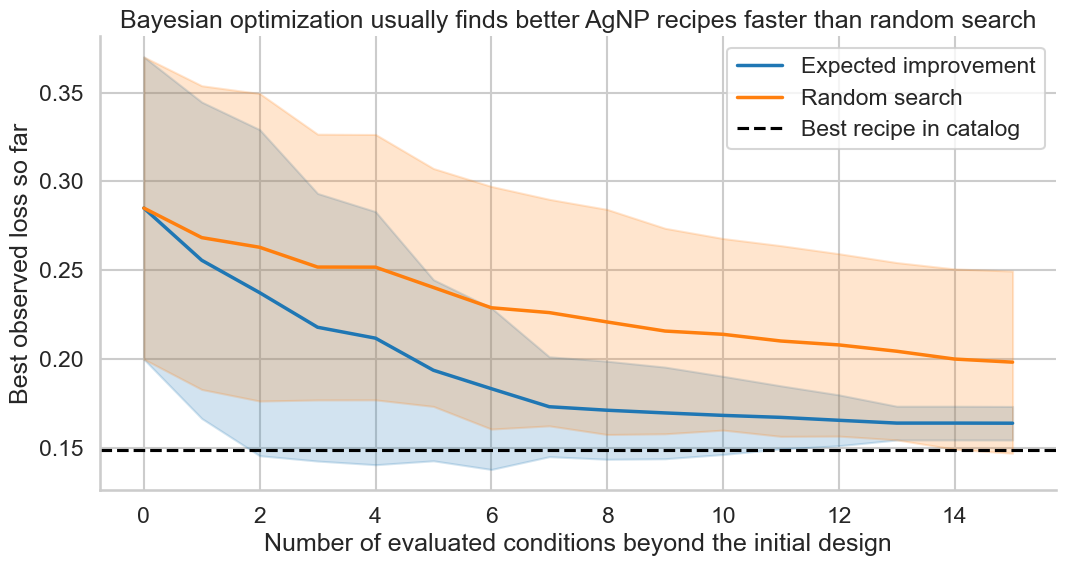

In [16]:
ei_traces, ei_final = summarize_strategy("ei", runs=40)
random_traces, random_final = summarize_strategy("random", runs=40)

x_axis = np.arange(ei_traces.shape[1])
ei_mean = ei_traces.mean(axis=0)
ei_std = ei_traces.std(axis=0)
random_mean = random_traces.mean(axis=0)
random_std = random_traces.std(axis=0)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(x_axis, ei_mean, label="Expected improvement", linewidth=2.5, color="#1f77b4")
ax.fill_between(x_axis, ei_mean - ei_std, ei_mean + ei_std, alpha=0.2, color="#1f77b4")
ax.plot(x_axis, random_mean, label="Random search", linewidth=2.5, color="#ff7f0e")
ax.fill_between(x_axis, random_mean - random_std, random_mean + random_std, alpha=0.2, color="#ff7f0e")
ax.axhline(y_catalog.min(), color="black", linestyle="--", label="Best recipe in catalog")
ax.set_xlabel("Number of evaluated conditions beyond the initial design")
ax.set_ylabel("Best observed loss so far")
ax.set_title("Bayesian optimization usually finds better AgNP recipes faster than random search")
ax.legend(loc="best")
plt.tight_layout()

print(f"Mean final best loss with EI:     {ei_final.mean():.4f}")
print(f"Mean final best loss with random: {random_final.mean():.4f}")
print(f"Global best loss in catalog:      {y_catalog.min():.4f}")


**Teaching point:** this is exactly the experimental-budget argument for Bayesian optimization.
If we only get a handful of synthesis rounds, we want each next experiment to be as informative as possible.


## 4. Multi-Objective Thinking: Cathode Design Tradeoffs

Many materials problems are not truly single-objective.
A battery cathode recipe might increase capacity but hurt cycle life or cost.
Below is a synthetic example to visualize why **Pareto fronts** matter.


In [17]:
nickel_fraction = np.linspace(0.45, 0.90, 80)
calcination_temp = np.linspace(650, 850, 80)
n_mesh, t_mesh = np.meshgrid(nickel_fraction, calcination_temp)

capacity = (
    175
    + 28 * np.exp(-((n_mesh - 0.76) / 0.12) ** 2 - ((t_mesh - 780) / 65) ** 2)
    + 4 * np.sin(8 * n_mesh)
)
stability = (
    82
    + 16 * np.exp(-((n_mesh - 0.60) / 0.10) ** 2 - ((t_mesh - 710) / 80) ** 2)
    - 7 * np.maximum(n_mesh - 0.72, 0)
)
cost = 40 + 70 * n_mesh + 0.04 * (t_mesh - 650)

design_df = pd.DataFrame(
    {
        "nickel_fraction": n_mesh.ravel(),
        "calcination_temp": t_mesh.ravel(),
        "capacity": capacity.ravel(),
        "stability": stability.ravel(),
        "cost_index": cost.ravel(),
    }
)


def pareto_mask(values):
    n_points = values.shape[0]
    mask = np.ones(n_points, dtype=bool)
    for i in range(n_points):
        if not mask[i]:
            continue
        dominated = np.all(values >= values[i], axis=1) & np.any(values > values[i], axis=1)
        mask[dominated] = False
        mask[i] = True
    return mask


pareto_points = design_df.loc[pareto_mask(design_df[["capacity", "stability"]].to_numpy())].copy()
pareto_points = pareto_points.sort_values("capacity")


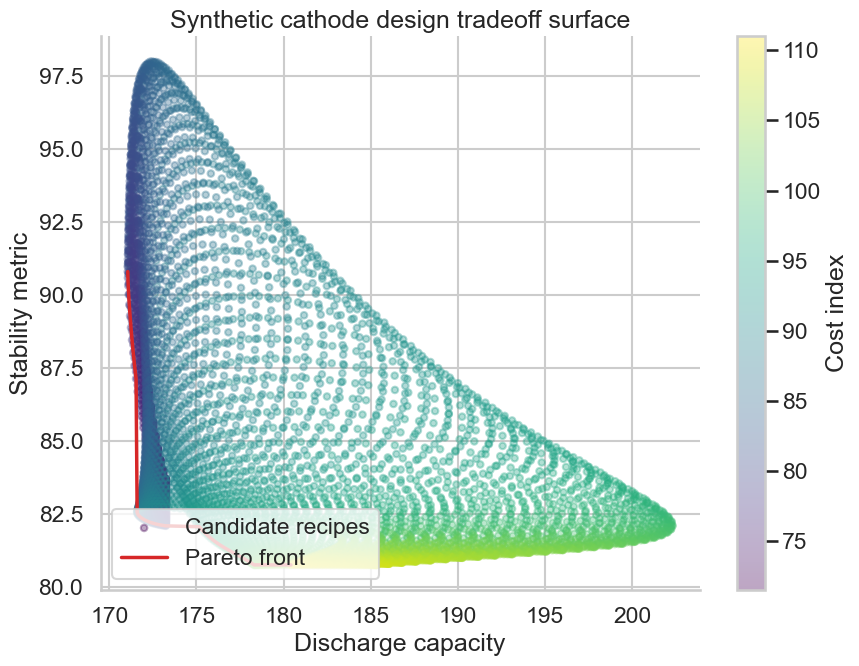

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    design_df["capacity"],
    design_df["stability"],
    c=design_df["cost_index"],
    cmap="viridis",
    alpha=0.35,
    s=22,
    label="Candidate recipes",
)
ax.plot(
    pareto_points["capacity"],
    pareto_points["stability"],
    color="#d62728",
    linewidth=2.5,
    label="Pareto front",
)
ax.set_xlabel("Discharge capacity")
ax.set_ylabel("Stability metric")
ax.set_title("Synthetic cathode design tradeoff surface")
ax.legend(loc="lower left")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Cost index")
plt.tight_layout()


## 5. Key Takeaways for Class

- A Gaussian process is the **surrogate**; Bayesian optimization is the **decision loop** built on top of it.
- Acquisition functions tell us where to sample next by mixing promise and uncertainty.
- Materials science is full of small, expensive, noisy datasets, so BO is often more practical than brute-force search.
- The AgNP example shows BO on a real dataset.
- The synthetic cathode example shows why many materials problems naturally become **multi-objective**.
- In the companion notebook, we will use **Honegumi** and the **Honegumi RAG assistant** to generate Ax-based Bayesian optimization code from structured options or natural-language problem descriptions.
